In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [9]:
# In[2]:
# ==========================================
# Step 1: Load Scored Active Borrower Data
# ==========================================
scored_df = pd.read_csv('02_scored_users_pca_filtered.csv')
print(f"--- Systemic Risk Detection Engine Started (N={len(scored_df)} Active Borrowers) ---")

--- Systemic Risk Detection Engine Started (N=1391 Active Borrowers) ---


In [10]:
# In[3]:
# ==========================================
# Step 2: Feature Engineering for Isolation Forest
# ==========================================
risk_features = ['log_total_borrow', 'balance_cv', 'log_tx_count']
risk_feature_matrix = scored_df[risk_features].fillna(0)

risk_scaler = StandardScaler()
scaled_risk_features = risk_scaler.fit_transform(risk_feature_matrix)

In [11]:
# In[4]:
# ==========================================
# Step 3: Train Isolation Forest for Anomaly Detection
# ==========================================
isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_samples='auto',
    random_state=42
)

scored_df['anomaly_label'] = isolation_forest.fit_predict(scaled_risk_features)
scored_df['anomaly_score'] = isolation_forest.decision_function(scaled_risk_features)

anomaly_count = len(scored_df[scored_df['anomaly_label'] == -1])
print(f"✅ Systemic Anomalies Identified: {anomaly_count} accounts (5% of active borrowers)")

✅ Systemic Anomalies Identified: 70 accounts (5% of active borrowers)


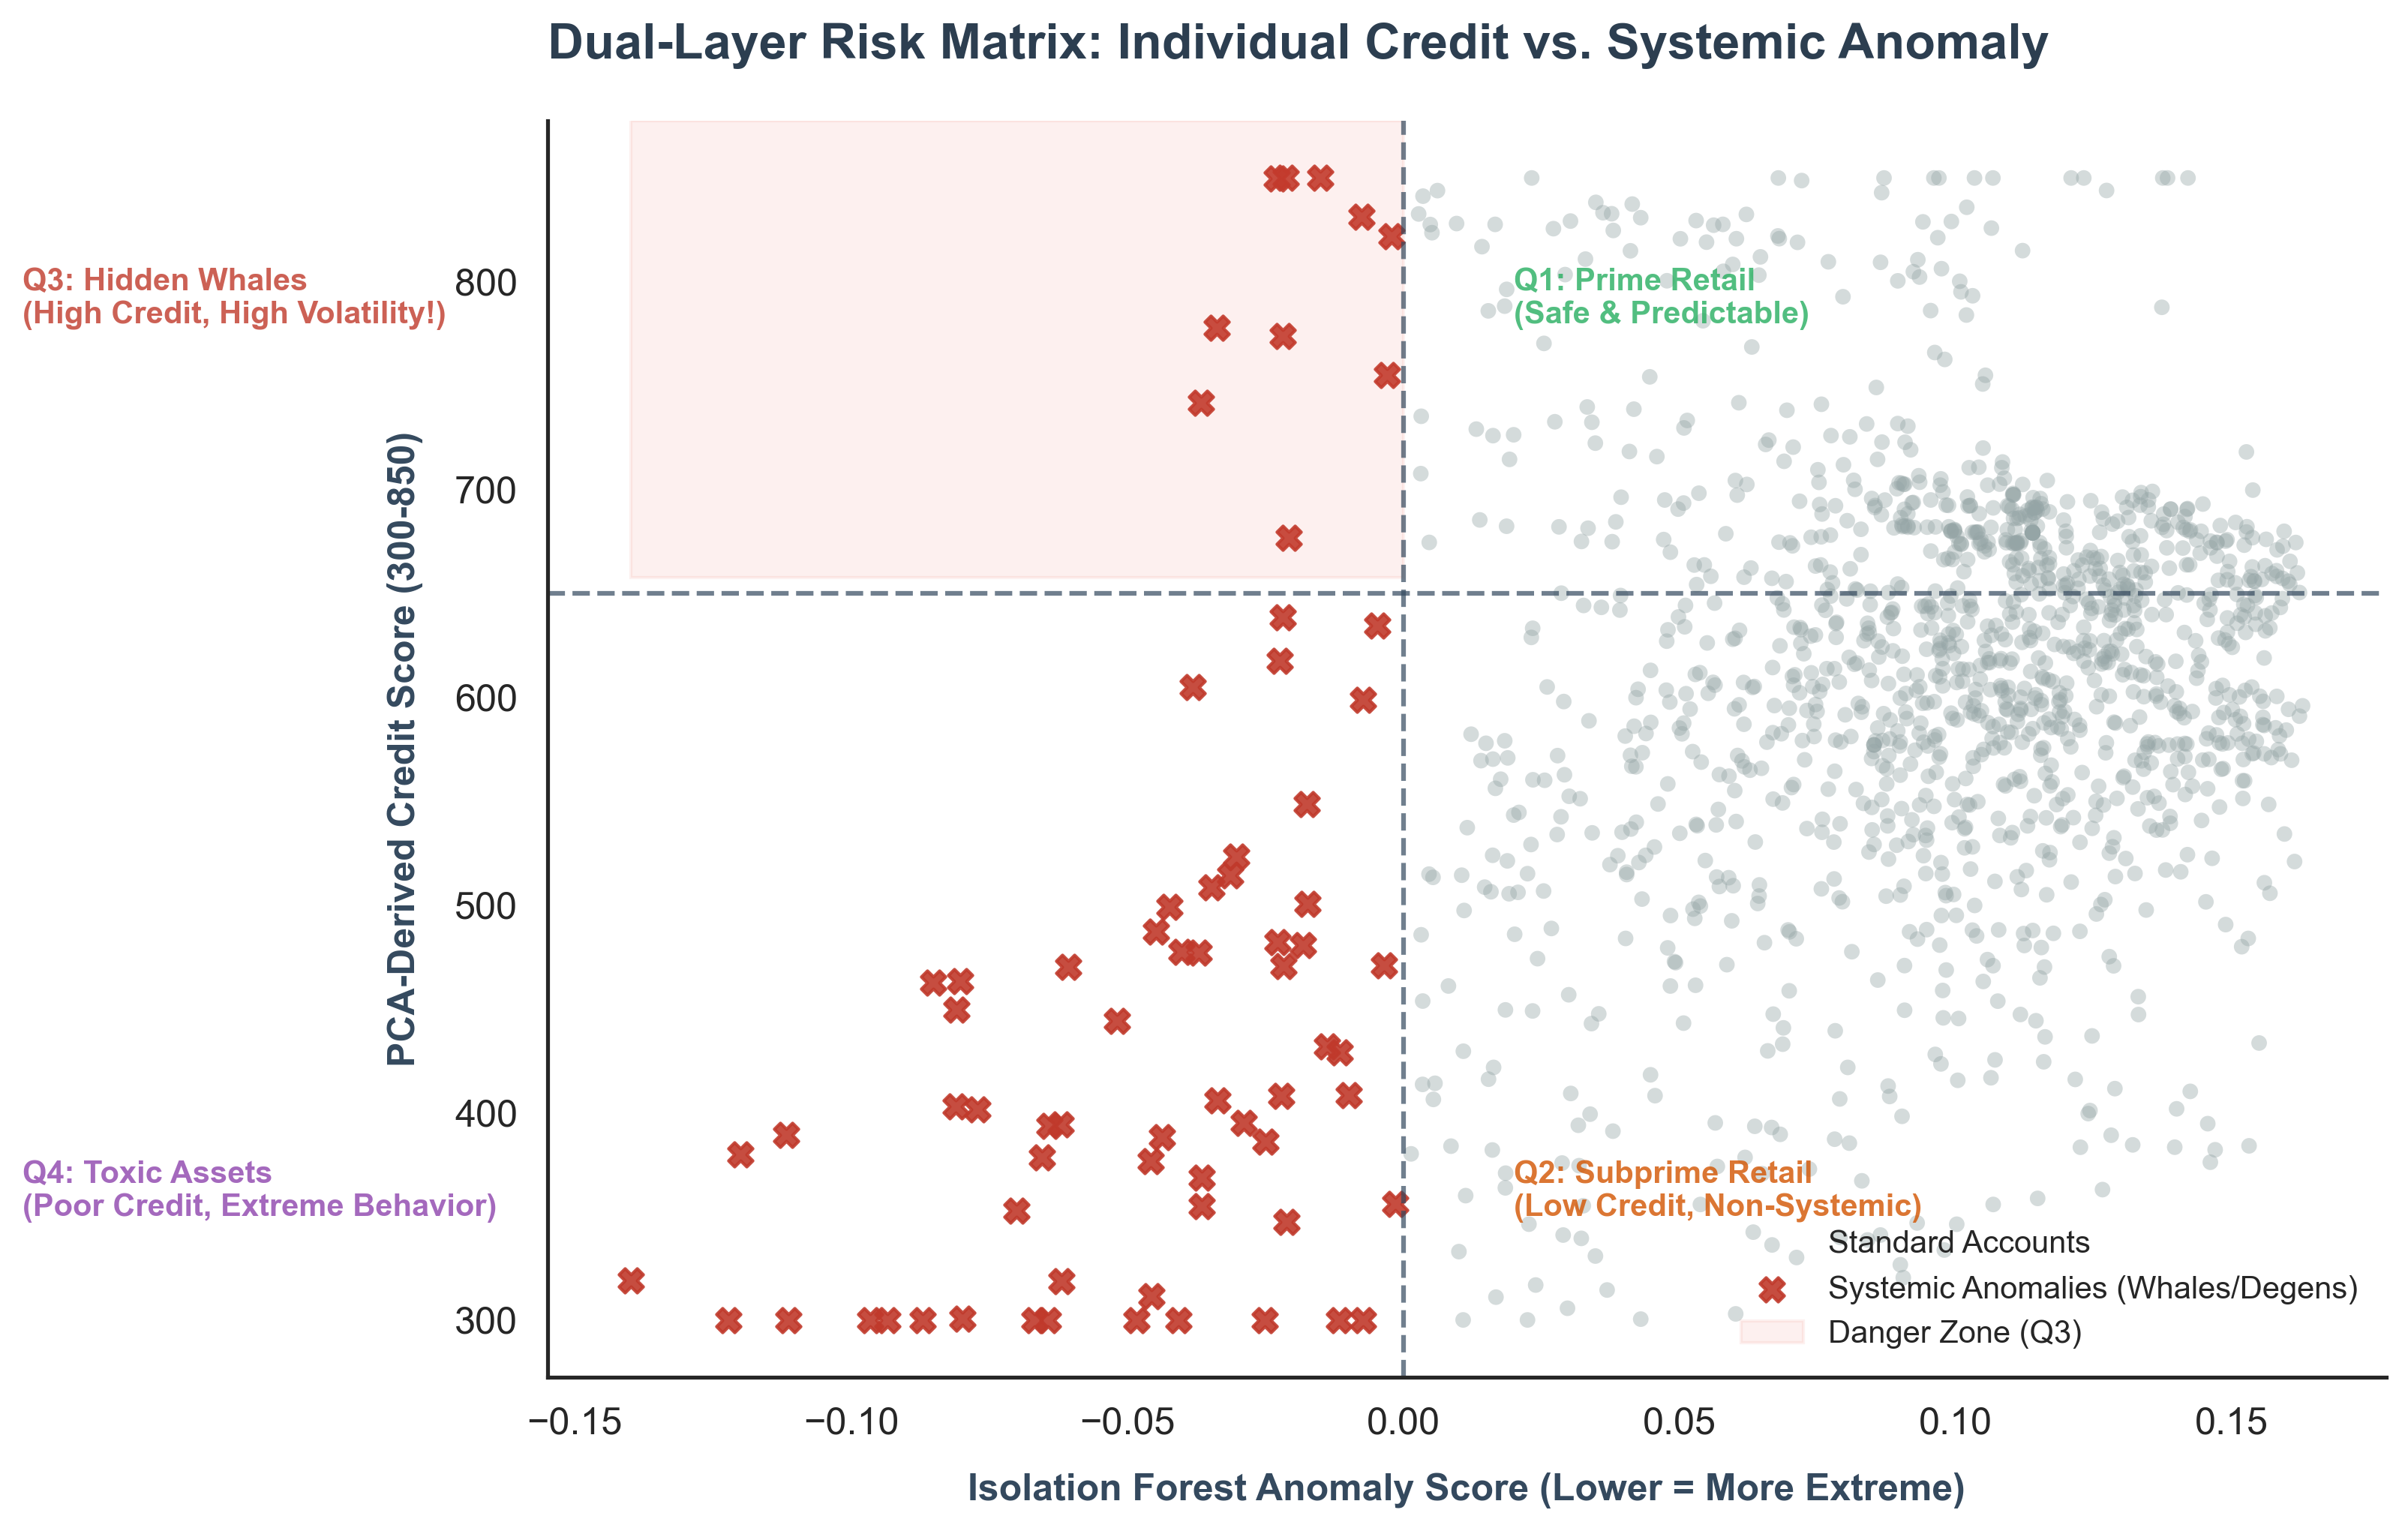

In [12]:
# In[5]:
# ==========================================
# Step 4-6: Single Risk Matrix Plot (ONE FIGURE ONLY)
# ==========================================
plt.figure(figsize=(11, 7), dpi=300)
sns.set_theme(style="white", font_scale=1.1)

normal_accounts = scored_df[scored_df['anomaly_label'] == 1]
anomaly_accounts = scored_df[scored_df['anomaly_label'] == -1]

plt.scatter(
    normal_accounts['anomaly_score'],
    normal_accounts['Scientific_Credit_Score'],
    alpha=0.4, color='#95A5A6', label='Standard Accounts', s=25, edgecolors='none'
)

plt.scatter(
    anomaly_accounts['anomaly_score'],
    anomaly_accounts['Scientific_Credit_Score'],
    alpha=0.9, color='#C0392B', marker='X', label='Systemic Anomalies (Whales/Degens)', s=60
)

prime_threshold = 650
plt.axvline(x=0, color='#34495E', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=prime_threshold, color='#34495E', linestyle='--', linewidth=1.5, alpha=0.7)

font_properties = {'fontsize': 10, 'fontweight': 'bold', 'alpha': 0.8}
plt.text(0.02, 780, 'Q1: Prime Retail\n(Safe & Predictable)', color='#27AE60', **font_properties)
plt.text(0.02, 350, 'Q2: Subprime Retail\n(Low Credit, Non-Systemic)', color='#D35400', **font_properties)
plt.text(-0.25, 780, 'Q3: Hidden Whales\n(High Credit, High Volatility!)', color='#C0392B', **font_properties)
plt.text(-0.25, 350, 'Q4: Toxic Assets\n(Poor Credit, Extreme Behavior)', color='#8E44AD', **font_properties)

plt.axvspan(
    scored_df['anomaly_score'].min(), 0,
    ymin=(prime_threshold-300)/(850-300), ymax=1,
    color='#E74C3C', alpha=0.08, label='Danger Zone (Q3)'
)

plt.title('Dual-Layer Risk Matrix: Individual Credit vs. Systemic Anomaly',
          fontsize=16, fontweight='heavy', color='#2C3E50', pad=20, loc='left')
plt.ylabel('PCA-Derived Credit Score (300-850)', fontsize=12, fontweight='bold', color='#34495E', labelpad=10)
plt.xlabel('Isolation Forest Anomaly Score (Lower = More Extreme)', fontsize=12, fontweight='bold', color='#34495E', labelpad=10)

sns.despine()
plt.legend(frameon=False, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
# In[6]:
# ==========================================
# Step 7: Save Final Risk Data & Executive Summary
# ==========================================
scored_df.to_csv('03_final_risk_model_results.csv', index=False)

q3_whale_count = len(anomaly_accounts[anomaly_accounts['Scientific_Credit_Score'] >= prime_threshold])
print("\n=== Executive Summary for Defense ===")
print(f"Critical Insight: {q3_whale_count} high-score accounts flagged as systemic anomalies (Q3: Hidden Whales).")
print("✅ Risk detection completed. Saved as 03_final_risk_model_results.csv")


=== Executive Summary for Defense ===
Critical Insight: 10 high-score accounts flagged as systemic anomalies (Q3: Hidden Whales).
✅ Risk detection completed. Saved as 03_final_risk_model_results.csv
